In [67]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [40]:
ds = pd.read_csv('iris.csv')
ds.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [41]:
iris = load_iris()
X = iris.data
y = iris.target


In [42]:
sc = StandardScaler()
x_scale = sc.fit_transform(X)

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x_scale,y,test_size=0.2,random_state=42)

In [44]:
k = range(1,11,2)
accuracies = []
for i in k:
    KNN = KNeighborsClassifier(n_neighbors=i)
    KNN.fit(x_train,y_train)
    y_pred = KNN.predict(x_test)
    acc = accuracy_score(y_pred,y_test)
    accuracies.append(acc)
    

In [45]:
accuracies

[0.9666666666666667, 1.0, 1.0, 1.0, 1.0]

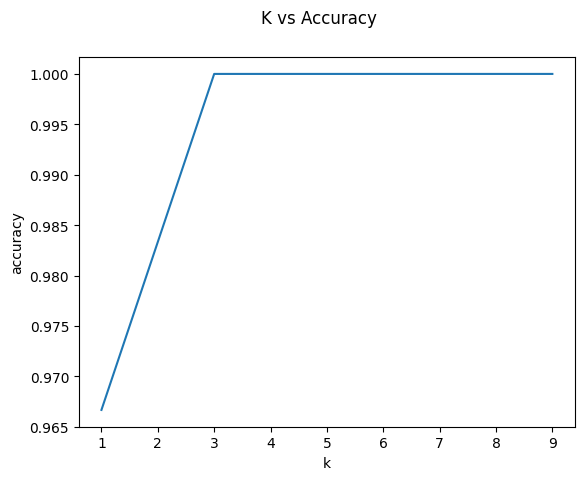

In [46]:
plt.plot(k,accuracies)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.suptitle('K vs Accuracy')
plt.show()

In [64]:
Best = k[np.argmax(accuracies)]
knn_best = KNeighborsClassifier(n_neighbors=Best)
knn_best.fit(x_train, y_train)
y_pred_best = knn_best.predict(x_test)

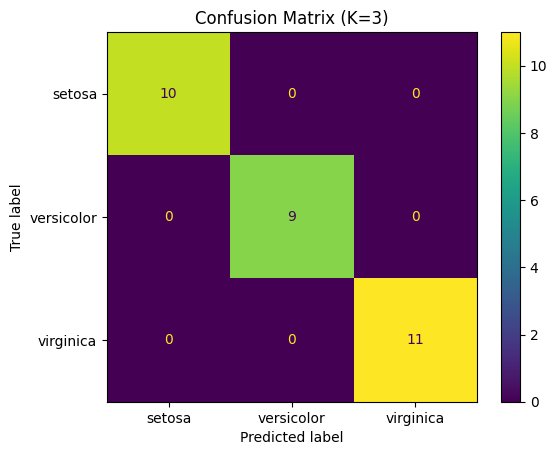

In [76]:
cm = confusion_matrix(y_pred_best,y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot()
plt.title(f'Confusion Matrix (K={Best})')
plt.show()

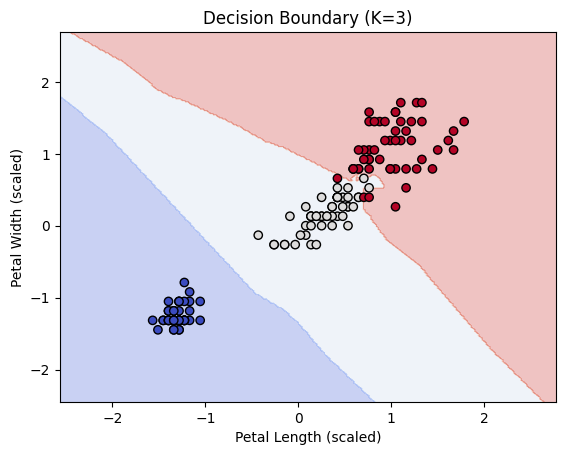

In [83]:
# Select 2 features for visualization
X_vis = x_scale[:, [2, 3]]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, test_size=0.2, random_state=42)

knn_vis = KNeighborsClassifier(n_neighbors=Best)
knn_vis.fit(X_train_vis, y_train_vis)

# Create mesh grid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title(f'Decision Boundary (K={Best})')
plt.show()